# NMSE and sampling uncertainty as a function of K

This notebook overlays reconstruction quality and prediction-normalized sampling dispersion in a single figure.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
from scipy.interpolate import PchipInterpolator

In [6]:
RESULT_DIR = Path('results/run_20260903_170728_epoch_23_medoid')
if not RESULT_DIR.exists():
    RESULT_DIR = Path('experiments') / RESULT_DIR

nmse_sources = pd.read_csv(RESULT_DIR / 'nmse_by_sampling_and_source.csv')
source_u = pd.read_csv(RESULT_DIR / 'uncertainty_by_source.csv')

mixture_nmse = (nmse_sources.groupby('mixture_id', as_index=False)
    .agg(K=('K', 'first'),
         frequency_overlap_pairwise=('frequency_overlap_pairwise', 'first'),
         nmse=('nmse', 'mean')))
source_nmse = (nmse_sources.groupby(['mixture_id', 'source'], as_index=False)
    .agg(K=('K', 'first'), snr=('snr', 'first'), nmse=('nmse', 'mean')))
mixture_u = (source_u.groupby('mixture_id', as_index=False)
    .agg(K=('K', 'first'),
         frequency_overlap_pairwise=('frequency_overlap_pairwise', 'first'),
         u_pred=('u_pred', 'mean')))

print(f'{len(mixture_nmse):,} mixtures loaded')

10,000 mixtures loaded


In [7]:
REPORT_INK = '#253047'
REPORT_GRID = '#DDE3EA'
CURVE_COLORS = ['#332288', '#88CCEE', '#44AA99', '#117733', '#999933',
                '#DDCC77', '#CC6677', '#882255', '#AA4499', '#661100']
K_COLORS = dict(zip(range(1, 11), CURVE_COLORS))
STYLE = {
    'font.family': 'Optima',
    'mathtext.fontset': 'stix',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#CBD2DC',
    'axes.labelcolor': REPORT_INK,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
}

def clean_axis(ax):
    ax.grid(axis='y', color=REPORT_GRID, linewidth=0.8)
    ax.grid(axis='x', color='#EEF2F6', linewidth=0.6)
    ax.tick_params(axis='both', length=0)
    ax.spines[['top', 'right']].set_visible(False)

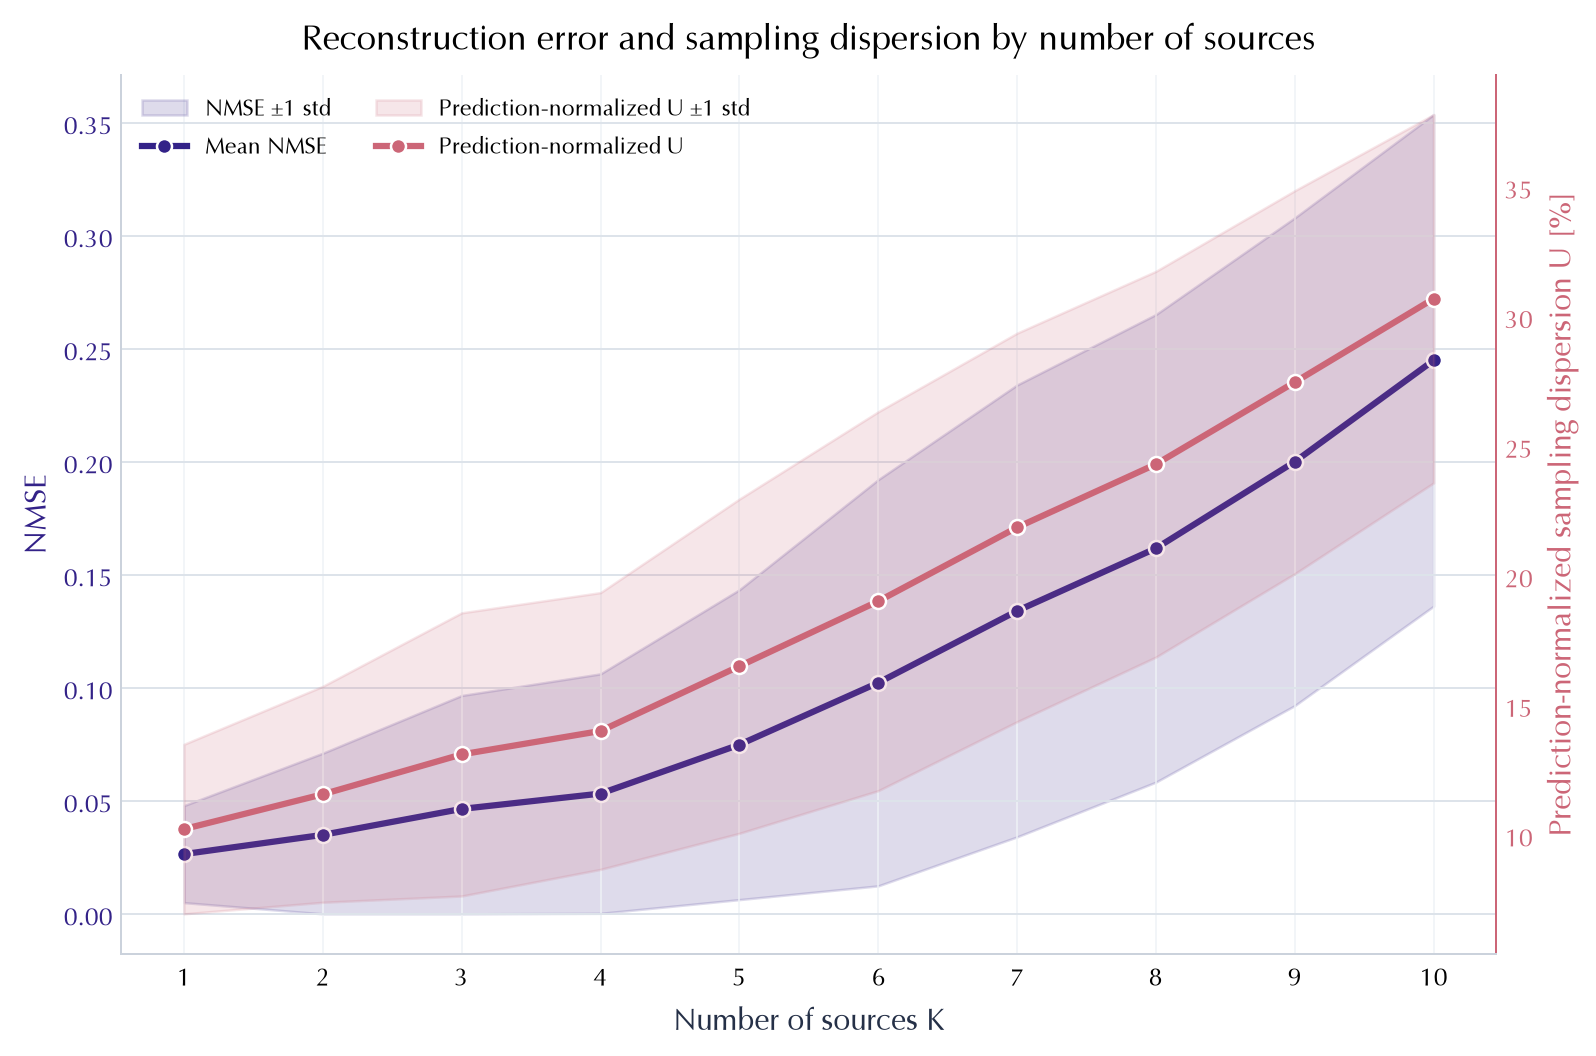

,mean_nmse,std_nmse,count_nmse,mean_u_pred,std_u_pred,count_u_pred
K,,,,,,
1,0.026418,0.021452,981,10.225151,3.271105,981
2,0.034939,0.036140,984,11.567692,4.167378,984
3,0.046414,0.050181,1016,13.105998,5.463365,1016
4,0.053201,0.052973,1034,14.010121,5.340537,1034
5,0.074833,0.068539,947,16.510637,6.449112,947
6,0.102236,0.089860,1036,19.017473,7.311204,1036
7,0.134016,0.099963,985,21.864760,7.497088,985
8,0.161711,0.103436,990,24.306085,7.443077,990
9,0.200029,0.107899,1013,27.469883,7.390533,1013


In [8]:
summary_nmse = mixture_nmse.groupby('K').nmse.agg(['mean', 'std', 'count'])
summary_u = mixture_u.groupby('K').u_pred.agg(['mean', 'std', 'count'])
summary_u[['mean', 'std']] *= 100

with plt.rc_context(STYLE):
    fig, ax_nmse = plt.subplots(figsize=(9.0, 6.0), dpi=180)
    ax_u = ax_nmse.twinx()

    nmse_low = (summary_nmse['mean'] - summary_nmse['std']).clip(lower=0)
    nmse_high = summary_nmse['mean'] + summary_nmse['std']
    ax_nmse.fill_between(
        summary_nmse.index, nmse_low, nmse_high, color='#332288', alpha=0.16,
        label='NMSE ±1 std',
    )
    ax_nmse.plot(
        summary_nmse.index, summary_nmse['mean'], color='#332288', marker='o',
        linewidth=2.5, markeredgecolor='white', label='Mean NMSE',
    )
    ax_nmse.set_xticks(summary_nmse.index)
    ax_nmse.set_xlabel('Number of sources K')
    ax_nmse.set_ylabel('NMSE', color='#332288')
    ax_nmse.tick_params(axis='y', colors='#332288')
    clean_axis(ax_nmse)

    u_low = (summary_u['mean'] - summary_u['std']).clip(lower=0)
    u_high = summary_u['mean'] + summary_u['std']
    ax_u.fill_between(
        summary_u.index, u_low, u_high, color='#CC6677', alpha=0.16,
        label='Prediction-normalized U ±1 std',
    )
    ax_u.plot(
        summary_u.index, summary_u['mean'], color='#CC6677', marker='o',
        linewidth=2.5, markeredgecolor='white', label='Prediction-normalized U',
    )
    ax_u.set_ylabel('Prediction-normalized sampling dispersion U [%]', color='#CC6677')
    ax_u.tick_params(axis='y', colors='#CC6677', length=0)
    ax_u.spines['top'].set_visible(False)
    ax_u.spines['right'].set_color('#CC6677')

    handles_nmse, labels_nmse = ax_nmse.get_legend_handles_labels()
    handles_u, labels_u = ax_u.get_legend_handles_labels()
    ax_nmse.legend(handles_nmse + handles_u, labels_nmse + labels_u,
                   loc='upper left', frameon=False, ncol=2)
    ax_nmse.set_title('Reconstruction error and sampling dispersion by number of sources', pad=10)
    fig.tight_layout()
    plt.show()

summary_nmse.join(summary_u, lsuffix='_nmse', rsuffix='_u_pred')

## NMSE and prediction-normalized uncertainty by SNR and frequency overlap

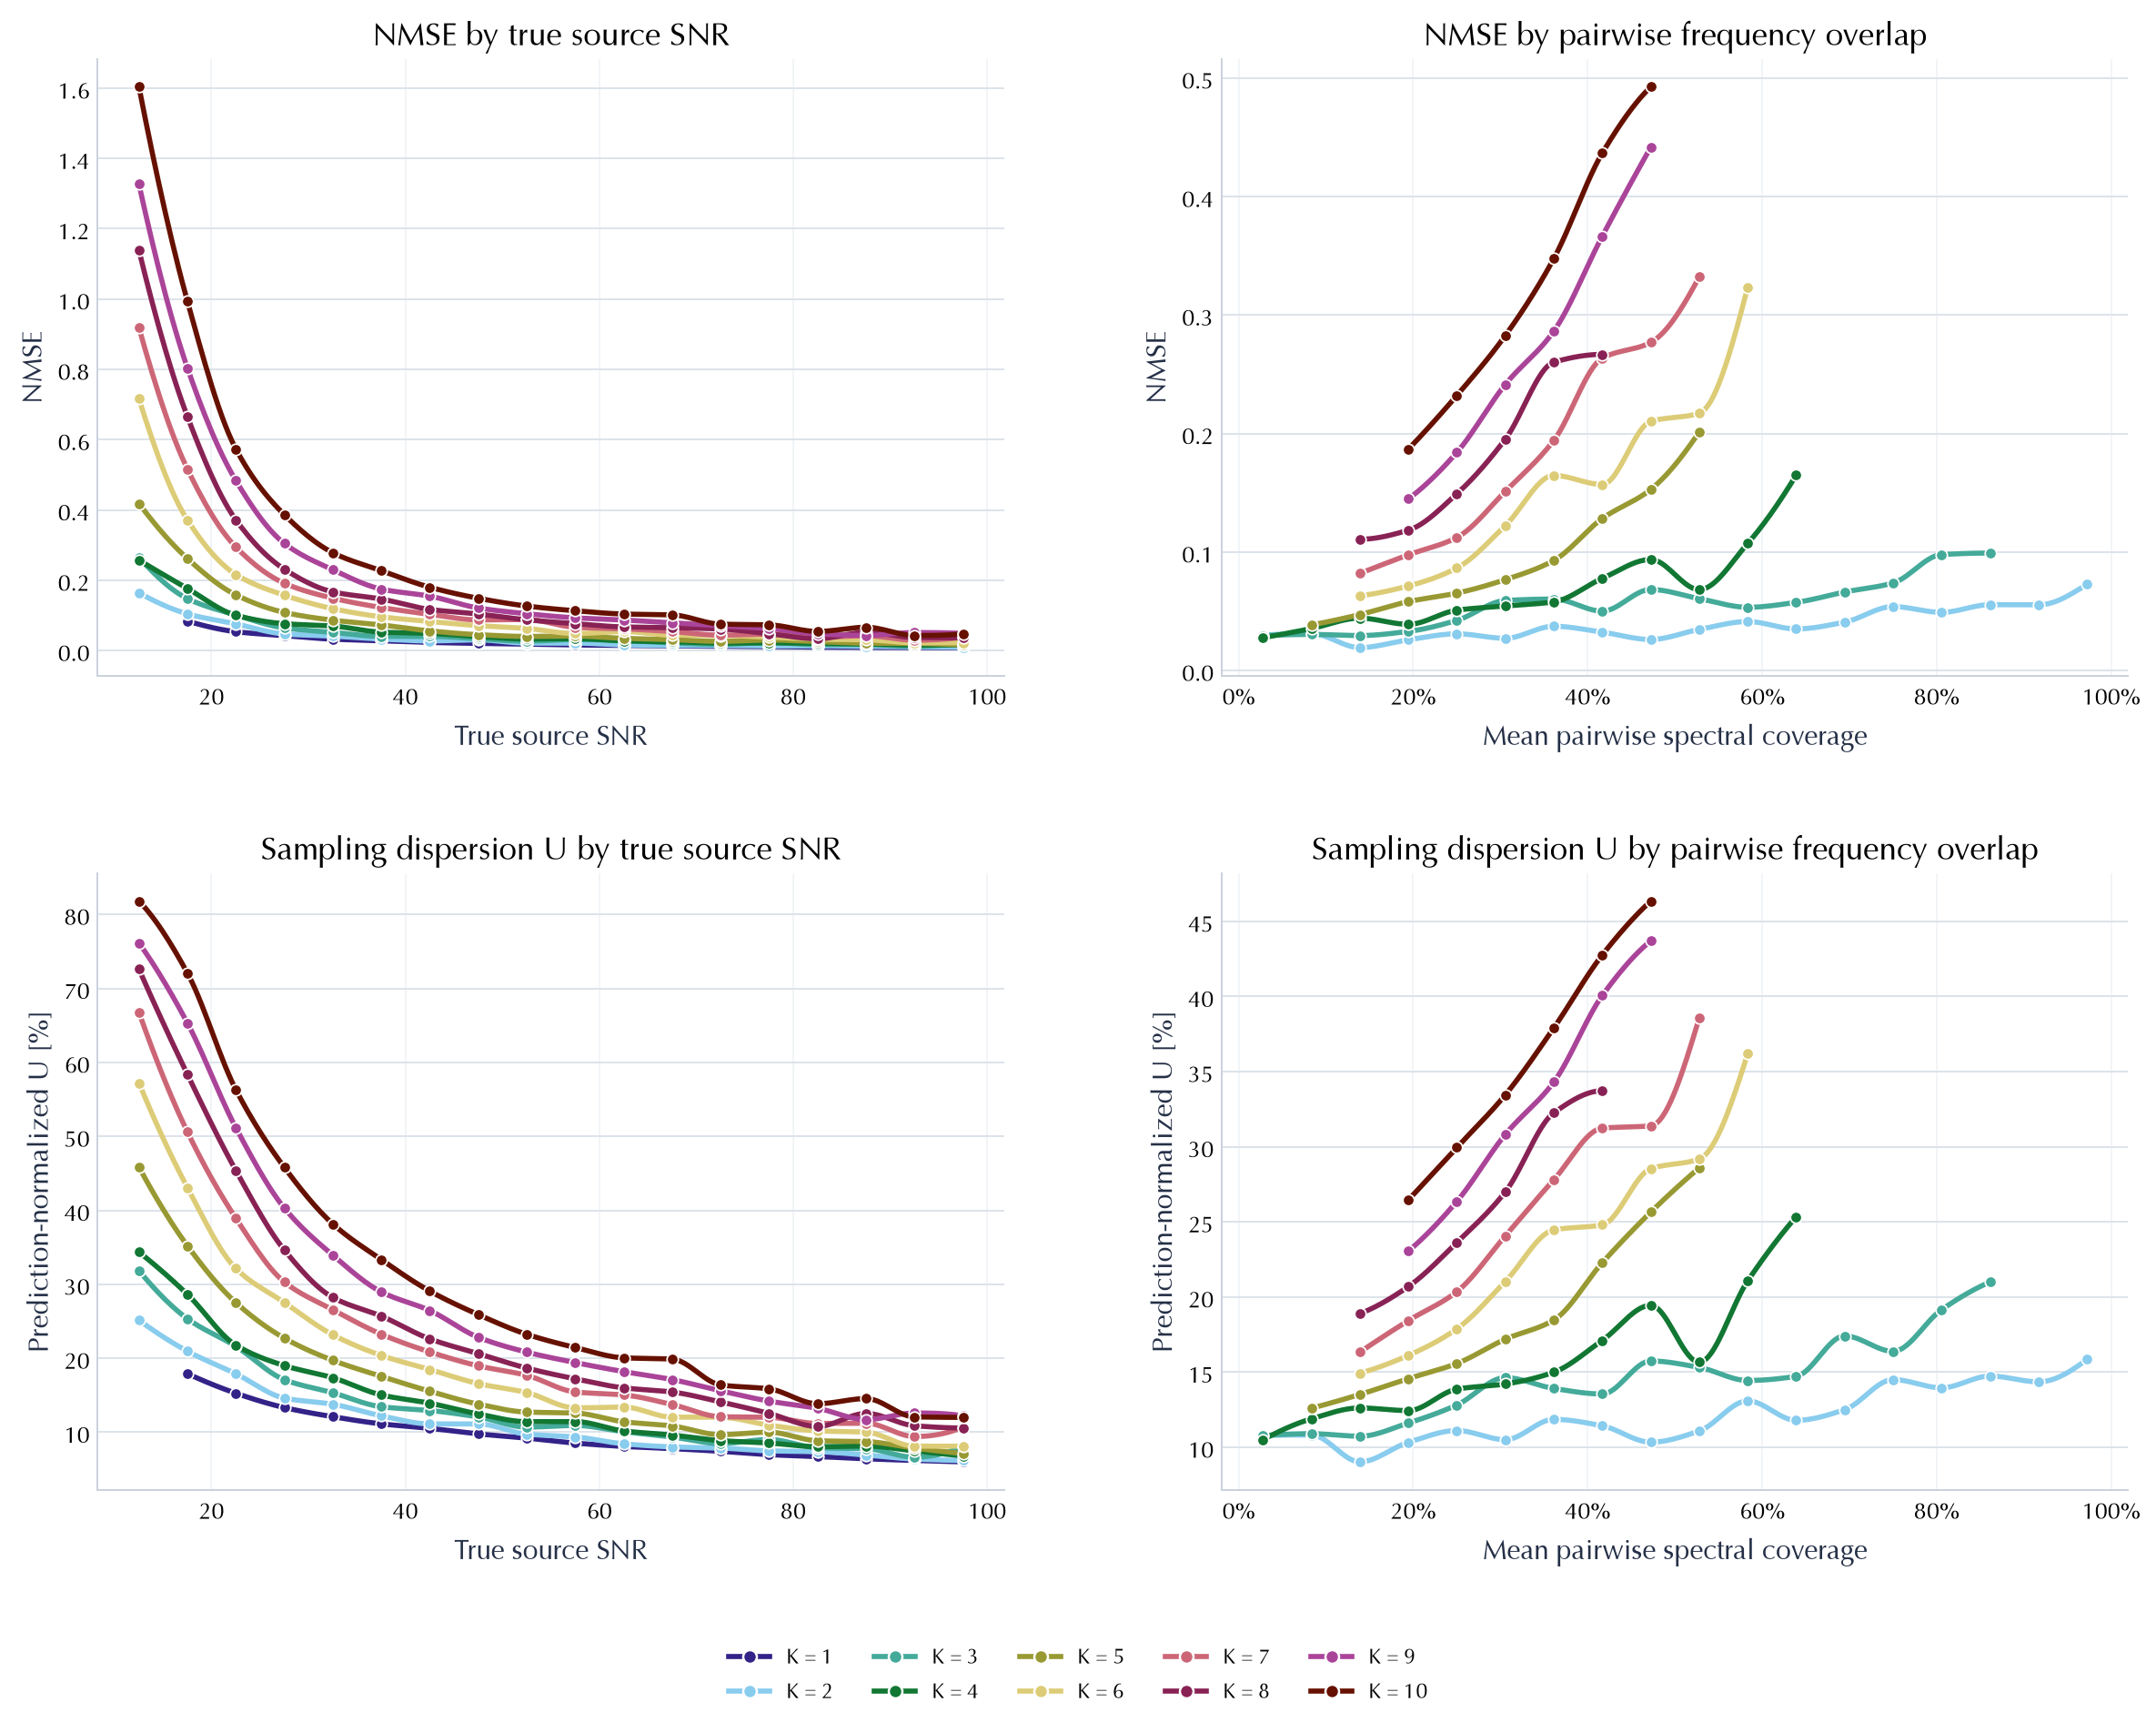

In [9]:
def add_k_curves(ax, data, metric, feature, edges, scale=1.0,
                 min_samples=10, skip_first_k=False):
    centers = 0.5 * (edges[:-1] + edges[1:])
    for k in sorted(data.K.unique()):
        if skip_first_k and k == 1:
            continue
        subset = data[data.K == k]
        bin_id = pd.cut(subset[feature], edges, labels=False, include_lowest=True)
        grouped = subset.assign(bin_id=bin_id).groupby('bin_id')[metric].agg(['mean', 'size'])
        values = np.full(len(centers), np.nan)
        valid_rows = grouped[grouped['size'] >= min_samples]
        values[valid_rows.index.astype(int)] = scale * valid_rows['mean']
        valid = np.isfinite(values)
        x, y = centers[valid], values[valid]
        color = K_COLORS[int(k)]
        if len(x) >= 3:
            smooth_x = np.linspace(x.min(), x.max(), 250)
            ax.plot(smooth_x, PchipInterpolator(x, y)(smooth_x), color=color,
                    linewidth=2.25, solid_capstyle='round')
            ax.scatter(x, y, color=color, s=25, zorder=3,
                       edgecolor='white', linewidth=0.7)
        elif len(x):
            ax.plot(x, y, color=color, linewidth=2.25, marker='o')
    clean_axis(ax)

snr_edges = np.linspace(source_nmse.snr.min(), source_nmse.snr.max(), 19)
overlap_edges = np.linspace(0.0, 1.0, 19)

with plt.rc_context(STYLE):
    fig, axes = plt.subplots(2, 2, figsize=(16.0, 11.5), dpi=180)

    add_k_curves(axes[0, 0], source_nmse, 'nmse', 'snr', snr_edges)
    axes[0, 0].set_title('NMSE by true source SNR')
    axes[0, 0].set_ylabel('NMSE')

    add_k_curves(axes[0, 1], mixture_nmse, 'nmse',
                 'frequency_overlap_pairwise', overlap_edges, skip_first_k=True)
    axes[0, 1].set_title('NMSE by pairwise frequency overlap')
    axes[0, 1].set_ylabel('NMSE')

    add_k_curves(axes[1, 0], source_u, 'u_pred', 'snr', snr_edges, scale=100)
    axes[1, 0].set_title('Sampling dispersion U by true source SNR')
    axes[1, 0].set_ylabel('Prediction-normalized U [%]')

    add_k_curves(axes[1, 1], mixture_u, 'u_pred',
                 'frequency_overlap_pairwise', overlap_edges,
                 scale=100, skip_first_k=True)
    axes[1, 1].set_title('Sampling dispersion U by pairwise frequency overlap')
    axes[1, 1].set_ylabel('Prediction-normalized U [%]')

    for ax in axes[:, 0]:
        ax.set_xlabel('True source SNR')
    for ax in axes[:, 1]:
        ax.set_xlabel('Mean pairwise spectral coverage')
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

    legend_handles = [
        Line2D([0], [0], color=K_COLORS[k], linewidth=2.25, marker='o',
               markeredgecolor='white', label=f'K = {k}')
        for k in sorted(K_COLORS)
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=5, frameon=False)
    fig.subplots_adjust(bottom=0.12, hspace=0.32, wspace=0.24)
    plt.show()